In [1]:
import kagglehub
import pandas as pd
import numpy as np
import polars as pl
import os
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from kagglehub import KaggleDatasetAdapter

C:\Users\YASH\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

path = kagglehub.dataset_download(r"ranja7/vehicle-insurance-customer-data")
print(path)

C:\Users\YASH\.cache\kagglehub\datasets\ranja7\vehicle-insurance-customer-data\versions\1


In [3]:
os.listdir(path)
df = pd.read_csv(os.path.join(path,os.listdir(path)[0]))

In [4]:
def aggregate_column(col_name:str):

    return df.groupby(col_name).agg(count = ("Customer","count")).reset_index()

In [5]:
aggregate_column("Vehicle Size")

,Vehicle Size,count
0,Large,946
1,Medsize,6424
2,Small,1764


In [6]:
aggregate_column("Vehicle Class")

,Vehicle Class,count
0,Four-Door Car,4621
1,Luxury Car,163
2,Luxury SUV,184
3,SUV,1796
4,Sports Car,484
5,Two-Door Car,1886


In [7]:
df.isna().sum()

Customer                         0
State                            0
Customer Lifetime Value          0
Response                         0
Coverage                         0
Education                        0
Effective To Date                0
EmploymentStatus                 0
Gender                           0
Income                           0
Location Code                    0
Marital Status                   0
Monthly Premium Auto             0
Months Since Last Claim          0
Months Since Policy Inception    0
Number of Open Complaints        0
Number of Policies               0
Policy Type                      0
Policy                           0
Renew Offer Type                 0
Sales Channel                    0
Total Claim Amount               0
Vehicle Class                    0
Vehicle Size                     0
dtype: int64

In [8]:
px.violin(data_frame=df,
          x="Marital Status",
          y="Income")

In [9]:
df.columns.to_list()

['Customer',
 'State',
 'Customer Lifetime Value',
 'Response',
 'Coverage',
 'Education',
 'Effective To Date',
 'EmploymentStatus',
 'Gender',
 'Income',
 'Location Code',
 'Marital Status',
 'Monthly Premium Auto',
 'Months Since Last Claim',
 'Months Since Policy Inception',
 'Number of Open Complaints',
 'Number of Policies',
 'Policy Type',
 'Policy',
 'Renew Offer Type',
 'Sales Channel',
 'Total Claim Amount',
 'Vehicle Class',
 'Vehicle Size']

In [10]:
df["Effective To Date"].min(),df["Effective To Date"].max()

('1/1/2011', '9/2/2011')

# Numerical Columns

In [11]:
df_num = df.select_dtypes(exclude=["object"])

In [12]:
df_num.head()

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
0,2763.519279,56274,69,32,5,0,1,384.811147
1,6979.535903,0,94,13,42,0,8,1131.464935
2,12887.431650,48767,108,18,38,0,2,566.472247
3,7645.861827,0,106,18,65,0,7,529.881344
4,2813.692575,43836,73,12,44,0,1,138.130879


<Axes: >

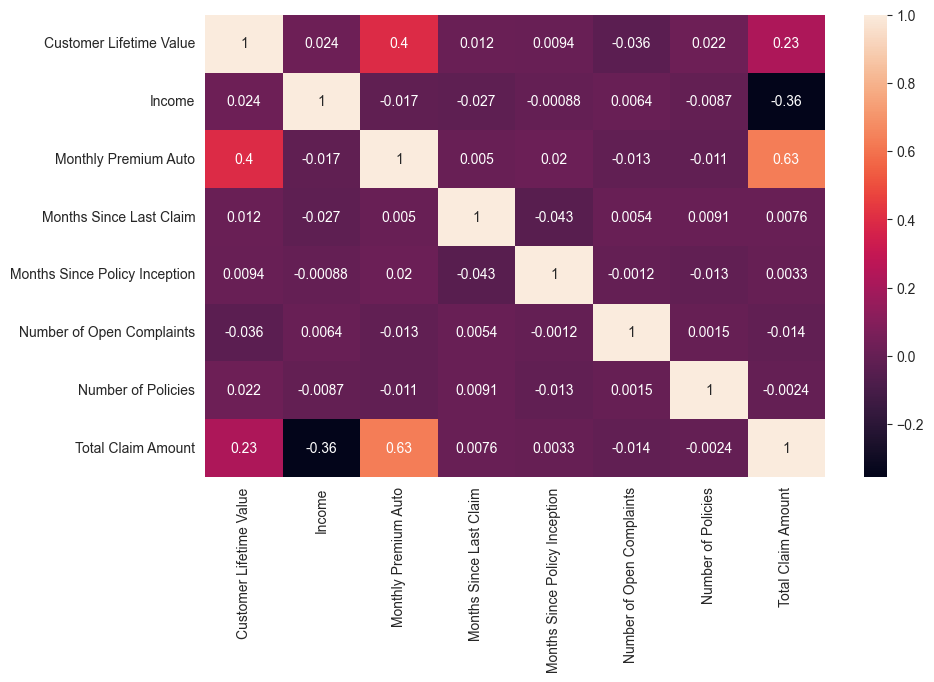

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df_num.corr(),annot=True)

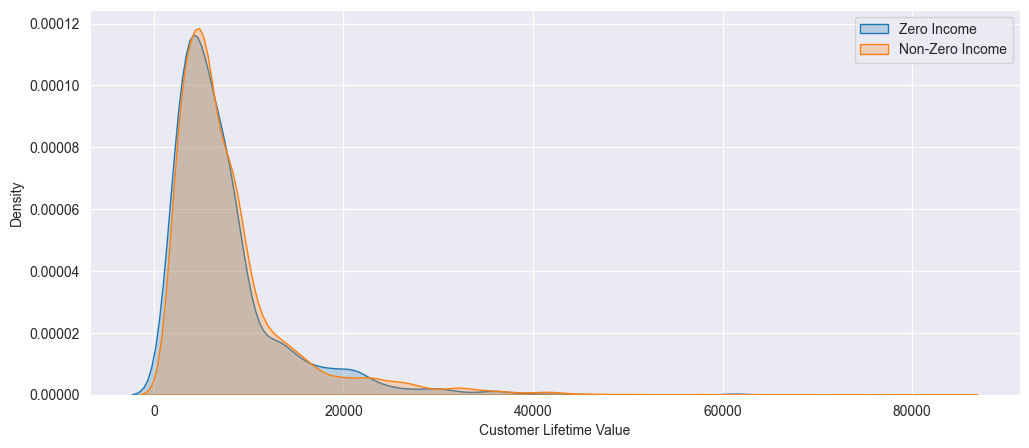

In [14]:
plt.figure(figsize=(12,5))
plt.grid(True)
sns.kdeplot(data=df[df["Income"]==0],x="Customer Lifetime Value",fill=True, label="Zero Income")

sns.kdeplot(data = df[df["Income"]>0], x ="Customer Lifetime Value", fill = True, label = "Non-Zero Income")

plt.legend()
plt.show()

<Axes: xlabel='Income', ylabel='Density'>

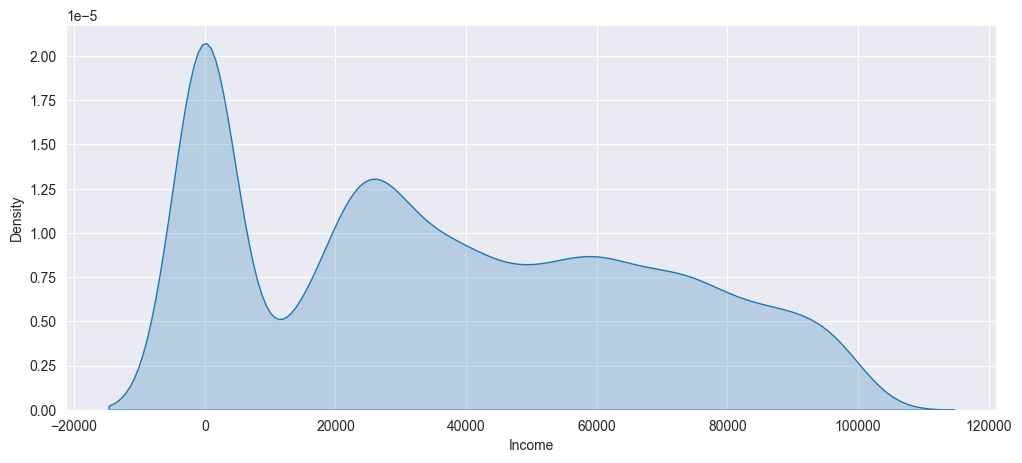

In [15]:
plt.figure(figsize=(12,5))
plt.grid(True)
sns.kdeplot(data=df_num,x="Income",fill=True)

<Axes: xlabel='Vehicle Class', ylabel='Total Claim Amount'>

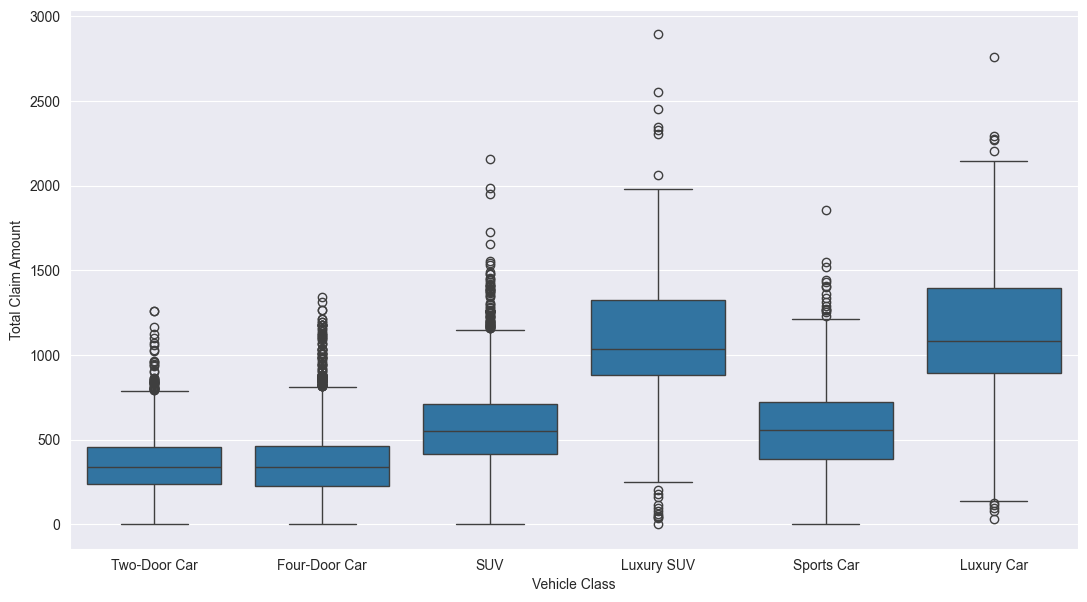

In [16]:
plt.figure(figsize=(13,7))
plt.grid(True)
sns.boxplot(data = df,
            y="Total Claim Amount",
            x="Vehicle Class",
            # hue="Location Code"
            )

<Axes: xlabel='Vehicle Size', ylabel='Total Claim Amount'>

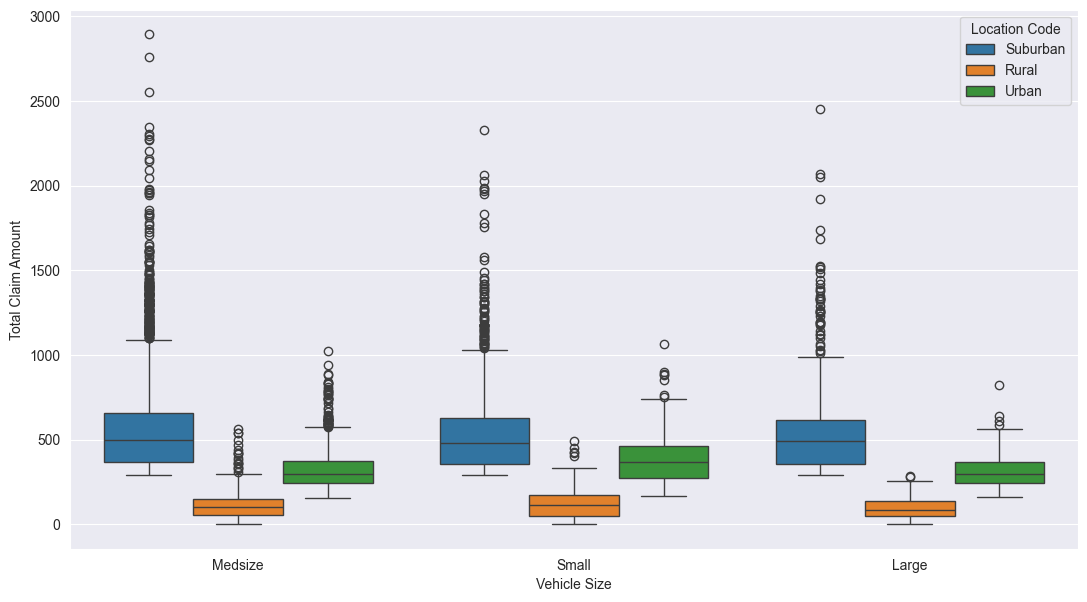

In [17]:
plt.figure(figsize=(13,7))
plt.grid(True)
sns.boxplot(data = df,
            y="Total Claim Amount",
            x="Vehicle Size",
            hue="Location Code"
            )

In [18]:
# vehicle size does not seem to influence claims amount

<Axes: xlabel='Location Code', ylabel='Total Claim Amount'>

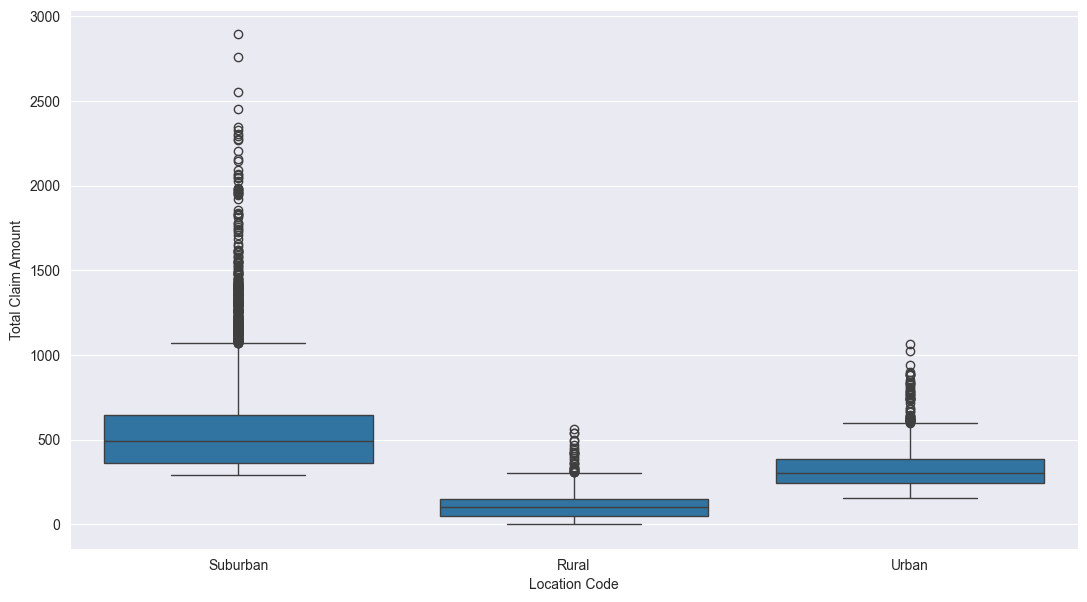

In [19]:
plt.figure(figsize=(13,7))
plt.grid(True)
sns.boxplot(data = df,
            y="Total Claim Amount",
            x="Location Code",
            # hue="Location Code"
            )

In [20]:
# Location code seems to be a factor

# Categorical Columns

In [21]:
def generate_histogram(_df:pd.DataFrame,col_name:str,hue=None):

    plt.figure(figsize=(12,5))
    plt.grid(True)

    sns.boxplot(
        data = _df,
        y = "Total Claim Amount",
        x = col_name,
        hue = hue,
    )

In [22]:
df_cat = df.select_dtypes(include="object")

In [23]:
df_cat_claims = pd.concat([df_cat,df["Total Claim Amount"]],axis=1)

In [24]:
df_cat_claims.head()

,Customer,State,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Location Code,Marital Status,Policy Type,Policy,Renew Offer Type,Sales Channel,Vehicle Class,Vehicle Size,Total Claim Amount
0,BU79786,Washington,No,Basic,Bachelor,2/24/11,Employed,F,Suburban,Married,Corporate Auto,Corporate L3,Offer1,Agent,Two-Door Car,Medsize,384.811147
1,QZ44356,Arizona,No,Extended,Bachelor,1/31/11,Unemployed,F,Suburban,Single,Personal Auto,Personal L3,Offer3,Agent,Four-Door Car,Medsize,1131.464935
2,AI49188,Nevada,No,Premium,Bachelor,2/19/11,Employed,F,Suburban,Married,Personal Auto,Personal L3,Offer1,Agent,Two-Door Car,Medsize,566.472247
3,WW63253,California,No,Basic,Bachelor,1/20/11,Unemployed,M,Suburban,Married,Corporate Auto,Corporate L2,Offer1,Call Center,SUV,Medsize,529.881344
4,HB64268,Washington,No,Basic,Bachelor,3/2/2011,Employed,M,Rural,Single,Personal Auto,Personal L1,Offer1,Agent,Four-Door Car,Medsize,138.130879


## State

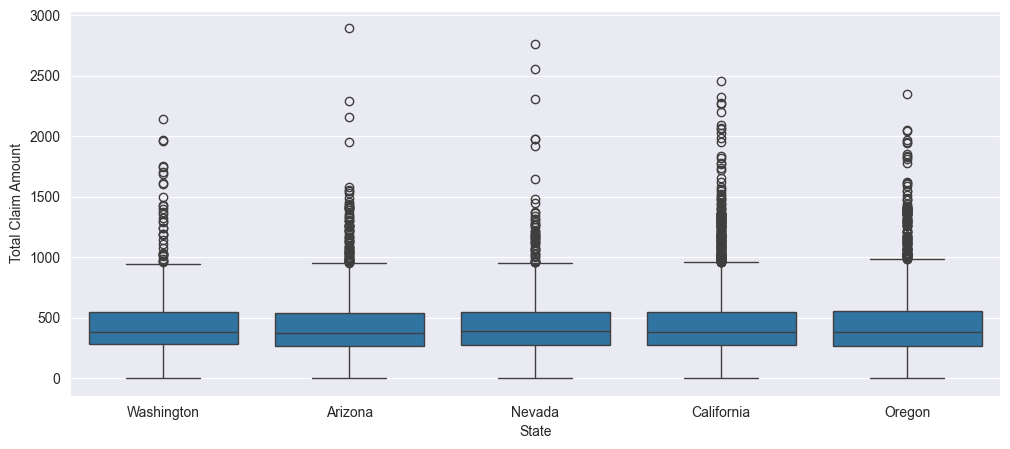

In [25]:
generate_histogram(df_cat_claims,"State")

## Employement Status

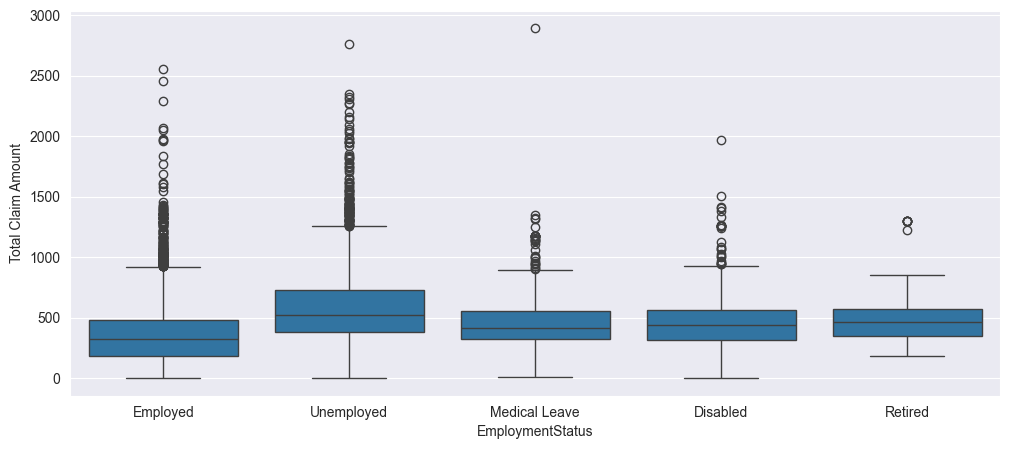

In [26]:
generate_histogram(df_cat_claims,"EmploymentStatus")

## Education

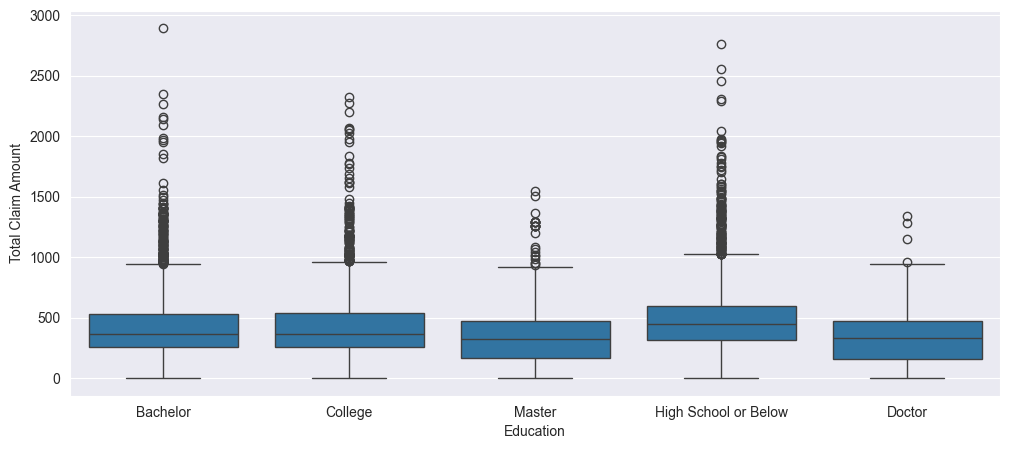

In [27]:
generate_histogram(df_cat_claims,"Education")

## Coverage

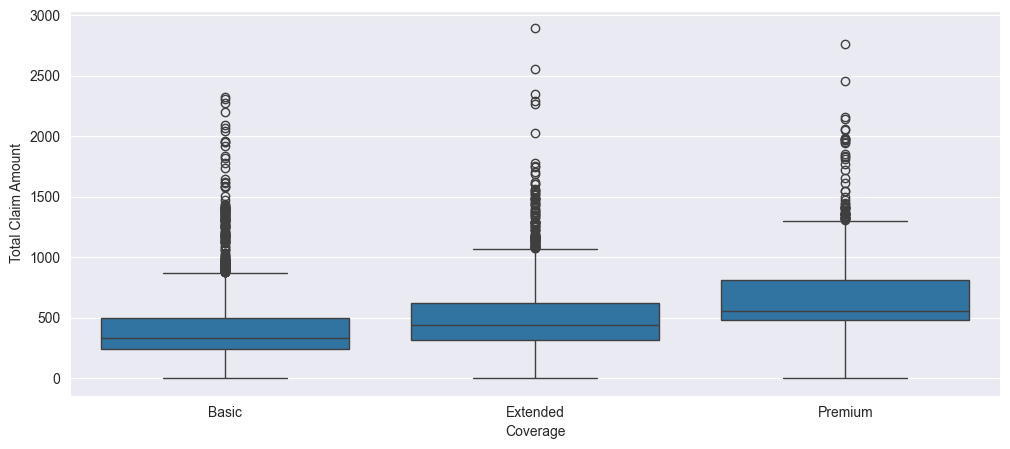

In [28]:
generate_histogram(df_cat_claims,"Coverage")

## Sales Channel

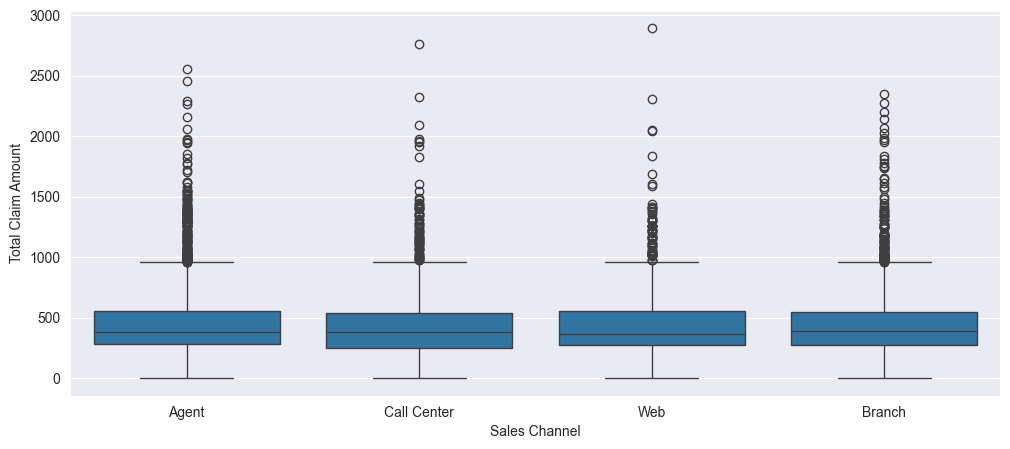

In [29]:
generate_histogram(df_cat_claims,"Sales Channel")

## Policy

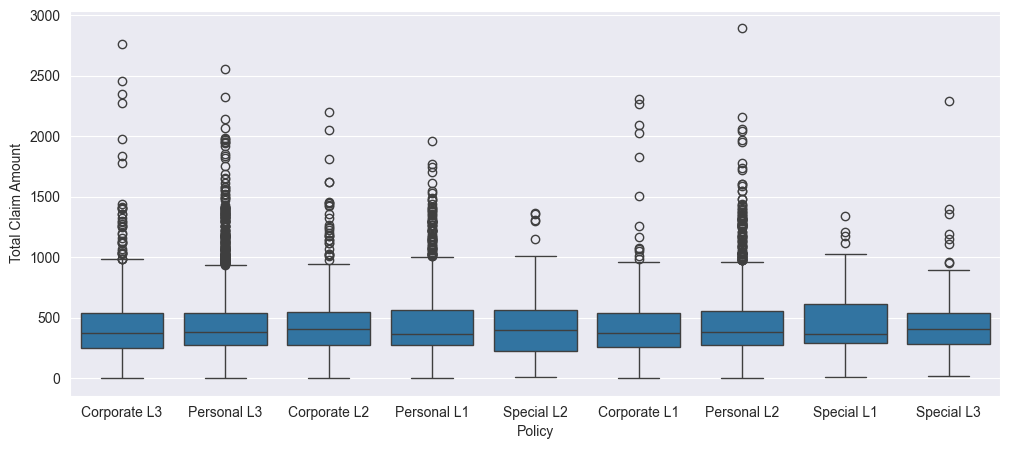

In [30]:
generate_histogram(df_cat_claims,"Policy")

## Vehicle Class

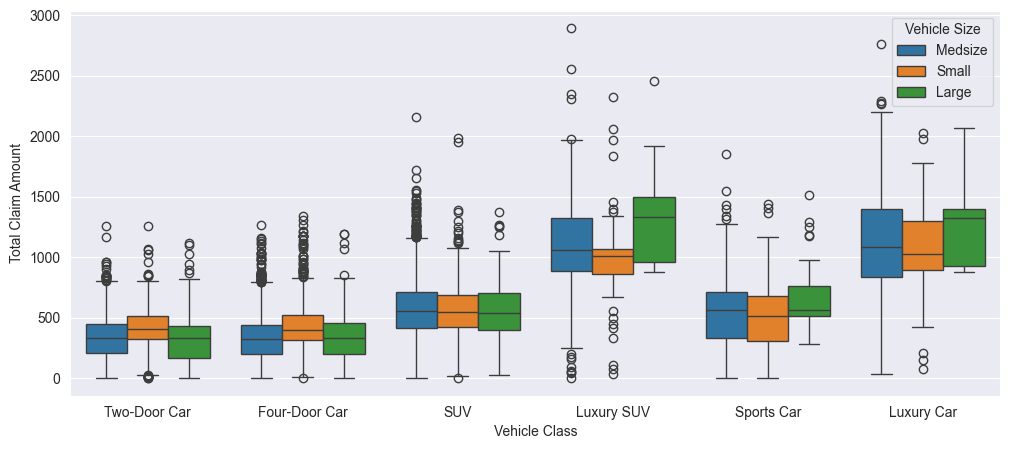

In [31]:
generate_histogram(df_cat_claims,"Vehicle Class",hue="Vehicle Size")

## Renew Offer Type

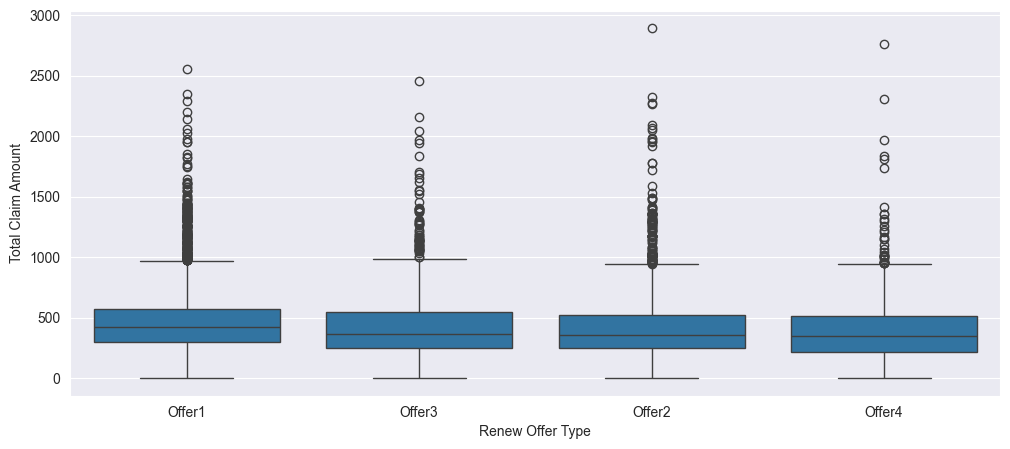

In [32]:
generate_histogram(df_cat_claims, "Renew Offer Type")

## Policy Type

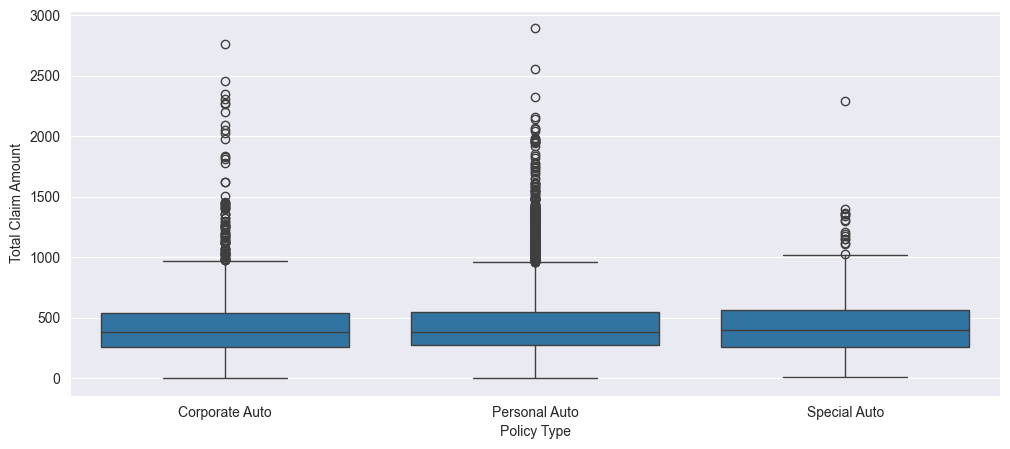

In [33]:
generate_histogram(df_cat_claims,"Policy Type")

In [122]:
from catboost import CatBoostClassifier, Pool, CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,root_mean_squared_error

In [123]:
df.dtypes

Customer                          object
State                             object
Customer Lifetime Value          float64
Response                          object
Coverage                          object
Education                         object
Effective To Date                 object
EmploymentStatus                  object
Gender                            object
Income                             int64
Location Code                     object
Marital Status                    object
Monthly Premium Auto               int64
Months Since Last Claim            int64
Months Since Policy Inception      int64
Number of Open Complaints          int64
Number of Policies                 int64
Policy Type                       object
Policy                            object
Renew Offer Type                  object
Sales Channel                     object
Total Claim Amount               float64
Vehicle Class                     object
Vehicle Size                      object
dtype: object

In [124]:
try:
    df_processed = df.drop(columns=["Effective To Date","Customer Lifetime Value"],axis=1)
except Exception as e:
    print(e)

In [125]:
num_cols=df_processed.select_dtypes(include=["float64","float32","int64","int32"]).columns.to_list()
cat_cols = df_processed.select_dtypes(include=["object"]).columns

In [126]:
X=df_processed.drop(columns=["Total Claim Amount"], axis=1)
y= df_processed["Total Claim Amount"]

In [127]:
cat_columns= X.select_dtypes(include=['object']).columns.tolist()

In [128]:
x_train,x_test,y_train,y_test = train_test_split(df_processed.drop(columns="Total Claim Amount",axis=1),df_processed["Total Claim Amount"],test_size=0.2)

In [129]:
train_pool=Pool(x_train,y_train,cat_features=cat_columns)

In [130]:
catboost_model= CatBoostRegressor(verbose=50,thread_count=8)

param_grid = {
    'depth': [3,4,6,5],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100,200]
}

In [131]:
catboost_model.grid_search(param_grid,X=train_pool,cv=3)

0:	learn: 518.7742911	test: 501.1409125	best: 501.1409125 (0)	total: 18.3ms	remaining: 1.82s
50:	learn: 344.6697886	test: 331.2958333	best: 331.2958333 (50)	total: 560ms	remaining: 538ms
99:	learn: 244.8339426	test: 233.6386860	best: 233.6386860 (99)	total: 1.06s	remaining: 0us

bestTest = 233.638686
bestIteration = 99

0:	loss: 233.6386860	best: 233.6386860 (0)	total: 1.09s	remaining: 25.2s
0:	learn: 500.4817876	test: 483.3018677	best: 483.3018677 (0)	total: 9.13ms	remaining: 903ms
50:	learn: 141.3556758	test: 132.1877463	best: 132.1877463 (50)	total: 508ms	remaining: 488ms
99:	learn: 123.6601705	test: 117.1540157	best: 117.1540157 (99)	total: 1.02s	remaining: 0us

bestTest = 117.1540157
bestIteration = 99

1:	loss: 117.1540157	best: 117.1540157 (1)	total: 2.13s	remaining: 23.4s
0:	learn: 477.7566957	test: 461.1326529	best: 461.1326529 (0)	total: 10.3ms	remaining: 1.02s
50:	learn: 124.7569199	test: 117.6033706	best: 117.5708738 (49)	total: 598ms	remaining: 574ms
99:	learn: 119.9772284

{'params': {'depth': 6, 'learning_rate': 0.1, 'iterations': 100},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39,
               40,
               41,
               42,
               43,
               44,
               45,
               46,
    

In [132]:
feature_importance=catboost_model.feature_importances_

feature_importance=[round(x,4) for x in feature_importance]

In [133]:
px.bar(x=catboost_model.feature_names_,y=feature_importance,title="Feature Importance",labels={"x":"Features","y":"Importance"})

In [134]:
shap_values = catboost_model.get_feature_importance(
    data=train_pool,
    type="ShapValues"
)

In [135]:
shaps = shap_values[:,:-1]

In [136]:
shap_importance = np.abs(shaps).mean(axis=0)

In [137]:
fig=px.bar(
    x=catboost_model.feature_names_,
    y=shap_importance,
)

fig.update_layout(
    title = 'Shap Values for Columns',
    xaxis_title = 'Feature',
    yaxis_title = 'Importance',
)

fig.show()

# Important Variables

In [138]:
cols_reduced = ['Monthly Premium Auto','Location Code','Vehicle Class','Marital Status','Coverage','Total Claim Amount']

In [139]:
df_processed2 = df[cols_reduced]

In [140]:
x_train,x_test,y_train,y_test = train_test_split(df_processed2.drop(columns=["Total Claim Amount"],axis=1),df_processed2["Total Claim Amount"],test_size=0.2)

In [141]:
x_train.select_dtypes(include=["object"]).columns

Index(['Location Code', 'Vehicle Class', 'Marital Status', 'Coverage'], dtype='object')

In [142]:
train_pool=Pool(x_train,y_train,cat_features=["Location Code","Vehicle Class","Marital Status","Coverage"])

In [143]:
catboost_model= CatBoostRegressor(verbose=50,thread_count=8)

param_grid = {
    'depth': [3,4,6,5],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100,200]
}

In [144]:
catboost_model.grid_search(param_grid,X=train_pool,cv=3)

0:	learn: 517.2959530	test: 515.8090990	best: 515.8090990 (0)	total: 7.7ms	remaining: 762ms
50:	learn: 362.6971488	test: 362.6709669	best: 362.6709669 (50)	total: 489ms	remaining: 470ms
99:	learn: 257.2823764	test: 257.8847886	best: 257.8847886 (99)	total: 991ms	remaining: 0us

bestTest = 257.8847886
bestIteration = 99

0:	loss: 257.8847886	best: 257.8847886 (0)	total: 1.02s	remaining: 23.5s
0:	learn: 500.7473272	test: 499.5757162	best: 499.5757162 (0)	total: 9.54ms	remaining: 944ms
50:	learn: 145.3075032	test: 145.6679632	best: 145.6679632 (50)	total: 502ms	remaining: 482ms
99:	learn: 126.8618428	test: 129.7980849	best: 129.7980849 (99)	total: 971ms	remaining: 0us

bestTest = 129.7980849
bestIteration = 99

1:	loss: 129.7980849	best: 129.7980849 (1)	total: 2s	remaining: 22s
0:	learn: 480.2702260	test: 479.5188277	best: 479.5188277 (0)	total: 7.58ms	remaining: 751ms
50:	learn: 126.9900716	test: 129.6992779	best: 129.6992779 (50)	total: 495ms	remaining: 476ms
99:	learn: 124.5090713	test

{'params': {'depth': 6, 'learning_rate': 0.05, 'iterations': 200},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39,
               40,
               41,
               42,
               43,
               44,
               45,
               46,
   

In [145]:
y_pred=catboost_model.predict(x_test)

In [146]:
print("RMSE:",root_mean_squared_error(y_test,y_pred))

RMSE: 126.66972141355986


In [151]:
residue = y_test-y_pred

In [152]:
p25,p50,p75,p90=np.percentile(residue,[25,50,75,90])

In [148]:
fig=px.scatter(x=y_test,
               y=y_pred,
            )

fig.add_shape(
    type="line",
    x0=0,
    y0=0,
    x1=1500,
    y1=1500
)

fig.update_layout(
    title="Predicted Vs Actual Claim Amount",
    xaxis_title="Claim Amount",
    yaxis_title="Predicted Claim Amount"

)

fig.show()

In [155]:
fig=px.scatter(x=y_test,
               y=y_pred,
            )

fig.add_scatter(
    x=y_test,
    y=y_test+p25,
    mode="lines",
    name="25th Percentile",
    line = dict(dash="dash"),
)

fig.add_scatter(
    x=y_test,
    y=y_test+p50,
    mode="lines",
    name="50th Percentile",
    line = dict(dash="dash"),
)

fig.add_scatter(
    x=y_test,
    y=y_test+p75,
    mode="lines",
    name="75th Percentile",
    line = dict(dash="dash"),
)

fig.add_scatter(
    x=y_test,
    y=y_test+p90,
    mode="lines",
    name="90th Percentile",
    line = dict(dash="dash"),
)

fig.update_layout(
    title="Predicted Vs Actual Claim Amount",
    xaxis_title="Claim Amount",
    yaxis_title="Predicted Claim Amount"

)

fig.show()